In [8]:
# Pip Installs
!pip install python-igraph
!pip install spotipy
!pip install selenium
!pip install python-dotenv
!pip install matplotlib
!pip install numpy
!pip install leidenalg
!pip install pandas  

  Using cached python_igraph-0.11.9-py3-none-any.whl.metadata (3.1 kB)
  Using cached igraph-0.11.9-cp39-abi3-macosx_11_0_arm64.whl.metadata (4.4 kB)
  Using cached texttable-1.7.0-py2.py3-none-any.whl.metadata (9.8 kB)
Using cached python_igraph-0.11.9-py3-none-any.whl (9.2 kB)
Using cached igraph-0.11.9-cp39-abi3-macosx_11_0_arm64.whl (1.8 MB)
Using cached texttable-1.7.0-py2.py3-none-any.whl (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [python-igraph]
  Using cached spotipy-2.25.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached redis-6.4.0-py3-none-any.whl.metadata (10 kB)
Using cached spotipy-2.25.1-py3-none-any.whl (31 kB)
Using cached redis-6.4.0-py3-none-any.whl (279 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [spotipy]
  Using cached selenium-4.35.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached trio-0.30.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached trio_websocket-0.12.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached typing_extensions-4.14.1-py

# meaning of words

- **Node**: A single entity in the graph (in this case, an artist).  
- **Edge**: A connection between two nodes (Ex: relationship between two artists).  
- **Weight**: A numerical value attached to an edge or node, representing strength or importance.  
- **Subgraph**: A smaller graph made from a subset of nodes and edges of the main graph.  
- **Generation**: A level or step in the exploration process (Ex: starting artist = Gen 0, related artists = Gen 1).  
- **Degree**: The number of edges (connections) linked to a node.  
- **Community**: A group of nodes that are more closely connected to each other than to the rest of the graph.  


In [2]:
# Cell 1: 
!pip install networkx

In [3]:
# Cell 2: Import Libraries
# This cell imports all required libraries for web scraping, data processing, and visualization
import os
import csv
from datetime import datetime
import time
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import sys

# Spotify API
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from dotenv import load_dotenv

# Web scraping
from selenium import webdriver
from selenium.webdriver.firefox.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

print("Libraries imported successfully!")


Libraries imported successfully!


In [4]:
# Cell 3: Setup Spotify API and Get Starting Artist (camelCase)
# Connects to Spotify API and searches for initial artist
load_dotenv("3510.env")
clientId = os.getenv("SPOTIFY_CLIENT_ID")
clientSecret = os.getenv("SPOTIFY_CLIENT_SECRET")

authManager = SpotifyClientCredentials(client_id=clientId, client_secret=clientSecret)
sp = spotipy.Spotify(auth_manager=authManager)

artistName = input("Enter an artist name: ")
searchResult = sp.search(q="artist:" + artistName, type="artist", limit=1)

if searchResult["artists"]["items"]:
    artistId = searchResult["artists"]["items"][0]["id"]
    artistName = searchResult["artists"]["items"][0]["name"]
else:
    print("Not found")
    raise ValueError("Artist not found")


Enter an artist name:  Trippie Redd


In [5]:
# Cell 4: Configuration Settings 
# Sets search parameters
maxGenerations = int(input("How many generations to search? (3-4): "))
artistsPerLevel = int(input("How many artists per level? (3-5): "))
maxRelatedPerArtist = 20

options = Options()
options.add_argument("--headless")


How many generations to search? (3-4):  4
How many artists per level? (3-5):  5


In [6]:
# Cell 5: Web Scraping Function 
# Scrapes Spotify web interface for related artists
def getRelatedArtists(artistId):
    driver = webdriver.Firefox(options=options)
    url = "https://open.spotify.com/artist/" + artistId + "/related"
    driver.get(url)
    time.sleep(2)
    
    section = WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.XPATH, "//section[contains(@aria-label, 'Fans also like')]"))
    )
    links = section.find_elements(By.CSS_SELECTOR, "a[href*='/artist/']")
    
    relatedArtists = {}
    for link in links:
        if len(relatedArtists) >= maxRelatedPerArtist:
            break
        artistName = link.text.strip()
        href = link.get_attribute("href")
        if artistName and "/artist/" in href:
            relatedId = href.split("/artist/")[1].split("?")[0]
            relatedArtists[relatedId] = artistName
    
    driver.quit()
    return relatedArtists


In [7]:
# Cell 6: Save and Load Data (single CSV version)
# Stores both artists and connections in one file

def saveDataToCsv(data, filename): #
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S") # good for multiple fiels with same artist
    mergedFile = filename + "_network_" + timestamp + ".csv"
    
    with open(mergedFile, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # One table with node + edge info
        writer.writerow(['artistId', 'artistName', 'generation', 'connectionType', 'targetId'])
        
        for artistId in data:
            artistInfo = data[artistId]
            # Row for the artist itself
            writer.writerow([artistId, artistInfo['name'], artistInfo['generation'], '', ''])
            # Rows for edges
            for targetId in artistInfo['explored']:
                writer.writerow([artistId, artistInfo['name'], artistInfo['generation'], 'explored', targetId])
            for targetId in artistInfo['all_related']:
                if targetId not in artistInfo['explored']:
                    writer.writerow([artistId, artistInfo['name'], artistInfo['generation'], 'related', targetId])
    
    return mergedFile


def loadDataFromCsv(mergedFile):
    artistData = {}
    df = pd.read_csv(mergedFile)
    
    for idex in range(len(df)):
        row = df.iloc[idex]
        artistId = row['artistId']
        artistName = row['artistName']
        generation = row['generation']
        connectionType = str(row['connectionType'])
        targetId = None if pd.isna(row['targetId']) else str(row['targetId']) ################
        
        if artistId not in artistData:
            artistData[artistId] = {
                'name': artistName,
                'generation': generation,
                'explored': [],
                'all_related': []
            }
        
        if connectionType == 'explored' and targetId:
            artistData[artistId]['explored'].append(targetId)
            artistData[artistId]['all_related'].append(targetId)
        elif connectionType == 'related' and targetId:
            artistData[artistId]['all_related'].append(targetId)
    
    return artistData


In [ ]:
# Cell 7: Data Collection or Loading (single CSV)
# Loads existing data or collects new data
existing = input("Load existing CSV? (y/n): ")

if existing == "y":
    useExisting = existing.lower().strip()
    csvFiles = []
    for f in os.listdir('.'):
        if "_network_" in f and f.endswith('.csv'):
            csvFiles.append(f)
    
    if csvFiles:
        for i in range(len(csvFiles)):
            filename = csvFiles[i]
            print(str(i + 1) + ". " + filename)
        
        choice = int(input("Select file: ")) - 1 # 1 = position 0
        mergedFile = csvFiles[choice]
        artistData = loadDataFromCsv(mergedFile)
    else: # Just in case
        useExisting = False
# https://docs.python.org/3/library/os.html#os.listdir
# https://docs.python.org/3/library/stdtypes.html#str.endswith

Load existing CSV? (y/n):  y


1. Felix!_network_20250929_112948.csv
2. TrippieRedd_network_20250929_013204.csv


In [9]:
# Cell 8: Collect New Data (minimal + progress prints, single CSV save)

# Runs web scraping to build network
if not useExisting:
    # I start using a dictionary and add to csv file after
    artistData = {
        artistId: {
            'name': artistName,
            'generation': 0,
            'explored': [],
            'all_related': []
        }
    }
    
    currentArtists = [artistId]


    # Heres the hard part

    # Go through every generatio we specified
    for generation in range(maxGenerations): 
        print("\nStarting Generation - " + str(generation))
        nextArtists = [] # this holds the "Fans Also Like" artists 

        # Go through each artist in the current generation
        for currentId in currentArtists:
            currentName = artistData[currentId]['name']
            print(" Exploring: " + currentName)
            
            try:
                related = getRelatedArtists(currentId)
            except Exception as e:
                print("\tSkipped " + currentName + " (error: " + str(e) + ")")
                related = {}
            
            artistData[currentId]['all_related'] = list(related.keys())
            
            exploredCount = 0
            for relId in related:
                relName = related[relId]
                if relId not in artistData and exploredCount < artistsPerLevel:
                    artistData[relId] = {
                        'name': relName,
                        'generation': generation + 1,
                        'explored': [],
                        'all_related': []
                    }
                    artistData[currentId]['explored'].append(relId)
                    nextArtists.append(relId)
                    exploredCount += 1
                    print("   Added new artist: " + relName)
        
        if not nextArtists:
            print(" No more new artists found.")
            break
        
        currentArtists = nextArtists
        
    # add this to a new csv file using my function
    fileBase = "".join(word.capitalize() for word in artistName.split())
    mergedFile = saveDataToCsv(artistData, fileBase)
    print("\nData collection complete. Saved to: " + mergedFile)


In [10]:
# Cell 9: Create Network Function 
# Builds NetworkX graph from data
def createNetwork(artistData):
    G = nx.Graph()
    
    # Collect connection counts for each artist 
    nodeList = []
    maxConnections = 0
    for artistId in artistData:
        artistInfo = artistData[artistId]
        connectionCount = len(artistInfo['all_related'])
        if connectionCount > maxConnections:
            maxConnections = connectionCount
        nodeList.append([artistInfo['name'], connectionCount])
    

    # Scale each artist's connections between 0 and 1 so we can size nodes fairly
    normalizedNodes = []
    if maxConnections > 0:
        for pair in nodeList:
            name = pair[0]
            count = pair[1]
            normalizedNodes.append([name, count / maxConnections])
            
    # If no connections exist, give everyone a small default weight (0.1)
    else: 
        for pair in nodeList:
            name = pair[0]
            normalizedNodes.append([name, 0.1])
    
    # Add nodes to graph with weights 
    for pair in normalizedNodes:
        nodeName = pair[0]
        nodeWeight = pair[1]
        G.add_node(nodeName, weight=nodeWeight)
    
    # Build weighted edges between artists
    edgeWeights = {}
    for sourceId in artistData:
        sourceInfo = artistData[sourceId]
        sourceName = sourceInfo['name']
        
        # Stronger edge for "explored"
        for targetId in sourceInfo['explored']:
            if targetId in artistData:
                targetName = artistData[targetId]['name']
                edgeKey = tuple(sorted([sourceName, targetName]))
                if edgeKey not in edgeWeights:
                    edgeWeights[edgeKey] = 0.8
        
        # Weaker edge for "all_related"
        for targetId in sourceInfo['all_related']:
            if targetId in artistData:
                targetName = artistData[targetId]['name']
                edgeKey = tuple(sorted([sourceName, targetName]))
                if edgeKey not in edgeWeights:
                    edgeWeights[edgeKey] = 0.3
    
    # Convert edge dictionary to list for NetworkX
    edgeList = []
    for edgePair in edgeWeights:
        weight = edgeWeights[edgePair]
        s = edgePair[0]
        t = edgePair[1]
        edgeList.append([s, t, weight])
    
    # Add edges to graph
    G.add_weighted_edges_from(edgeList)
    
    return G, normalizedNodes


# https://networkx.org/documentation/stable/reference/classes/graph.html   
# https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.add_node.html
# https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.add_weighted_edges_from.html
# https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html


In [11]:
# Cell 10: Visualization Function (handles bad characters in names)
# Creates network visualization safely
def visualizeNetwork(G, normalizedNodes, artistData, title="Artist Network"):
    plt.figure(figsize=(14, 14))

    # --- Define problematic characters that break matplotlib mathtext ---
    badChars = ["$", "{", "}", "\\", "%", "#", "&", "^", "_"]

    # Filter out nodes that contain bad characters
    safeNodes = []
    for n in G.nodes():
        if not any(c in str(n) for c in badChars):
            safeNodes.append(n)

    # Work on a filtered subgraph
    G2 = G.subgraph(safeNodes)

    # If the title has bad chars, use a safe fallback
    if any(c in str(title) for c in badChars):
        title = "Artist Network"

    # --- Build node size list based on normalized weights ---
    nodeOrder = list(G2.nodes())
    nodeSizes = []
    for node in nodeOrder:
        for pair in normalizedNodes:
            nodeName = pair[0]
            nodeWeight = pair[1]
            if nodeName == node:
                nodeSizes.append(nodeWeight * 1200 + 200)
                break

    # --- Define generation colors ---
    generationColors = ['purple', 'red', 'orange', 'yellow', 'green',
                        'cyan', 'blue', 'magenta', 'brown', 'pink']

    # --- Map artist names to their generation ---
    nameToGen = {}
    for artistId in artistData:
        artistInfo = artistData[artistId]
        if artistInfo['name'] in safeNodes:  # Only safe nodes
            nameToGen[artistInfo['name']] = artistInfo['generation']

    # --- Assign node colors ---
    nodeColors = []
    for node in nodeOrder:
        if node in nameToGen:
            gen = nameToGen[node]
            nodeColors.append(generationColors[min(gen, 9)])
        else:
            nodeColors.append('gray')

    # --- Assign edge weights + colors ---
    edgeColors = []
    edgeWeightsByGen = []
    for edge in G2.edges():
        source = edge[0]
        target = edge[1]
        sourceGen = nameToGen.get(source, 0)
        targetGen = nameToGen.get(target, 0)
        avgGen = (sourceGen + targetGen) / 2

        # Color edges depending on generation similarity
        if sourceGen == targetGen:
            edgeColors.append('#E0E0E0')
        elif abs(sourceGen - targetGen) == 1:
            higherGen = max(sourceGen, targetGen)
            edgeColors.append(generationColors[min(higherGen, 9)])
        else:
            edgeColors.append('#404040')

        # Scale edge thickness by weight + generation
        baseWeight = G2[source][target]['weight']
        genScale = 0.5 ** (avgGen / 1.5)
        finalWeight = baseWeight * 3 * genScale
        edgeWeightsByGen.append(finalWeight)

    # --- Layout + Draw ---
    pos = nx.spring_layout(G2, k=0.8, iterations=30, seed=42)
    nx.draw(G2, pos,
            with_labels=True,
            node_size=nodeSizes,
            node_color=nodeColors,
            width=edgeWeightsByGen,
            edge_color=edgeColors,
            alpha=0.6,
            font_size=7,
            font_weight='bold')

    # --- Add title ---
    plt.title(title, fontsize=16, fontweight='bold', pad=20)

    # --- Add legend if multiple generations ---
    uniqueGens = sorted(set(nameToGen.values()))
    if len(uniqueGens) > 1:
        from matplotlib.patches import Patch
        legend = []
        for g in uniqueGens[:10]:
            patch = Patch(facecolor=generationColors[g], label="Generation " + str(g))
            legend.append(patch)
        plt.legend(handles=legend, loc='upper left', fontsize=10)

    plt.axis('off')

    # --- Save figure safely (remove bad chars from filename) ---
    safeTitle = "".join(ch for ch in title if ch.isalnum() or ch == " ")
    filename = "".join(word.capitalize() for word in safeTitle.split()) + ".png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()


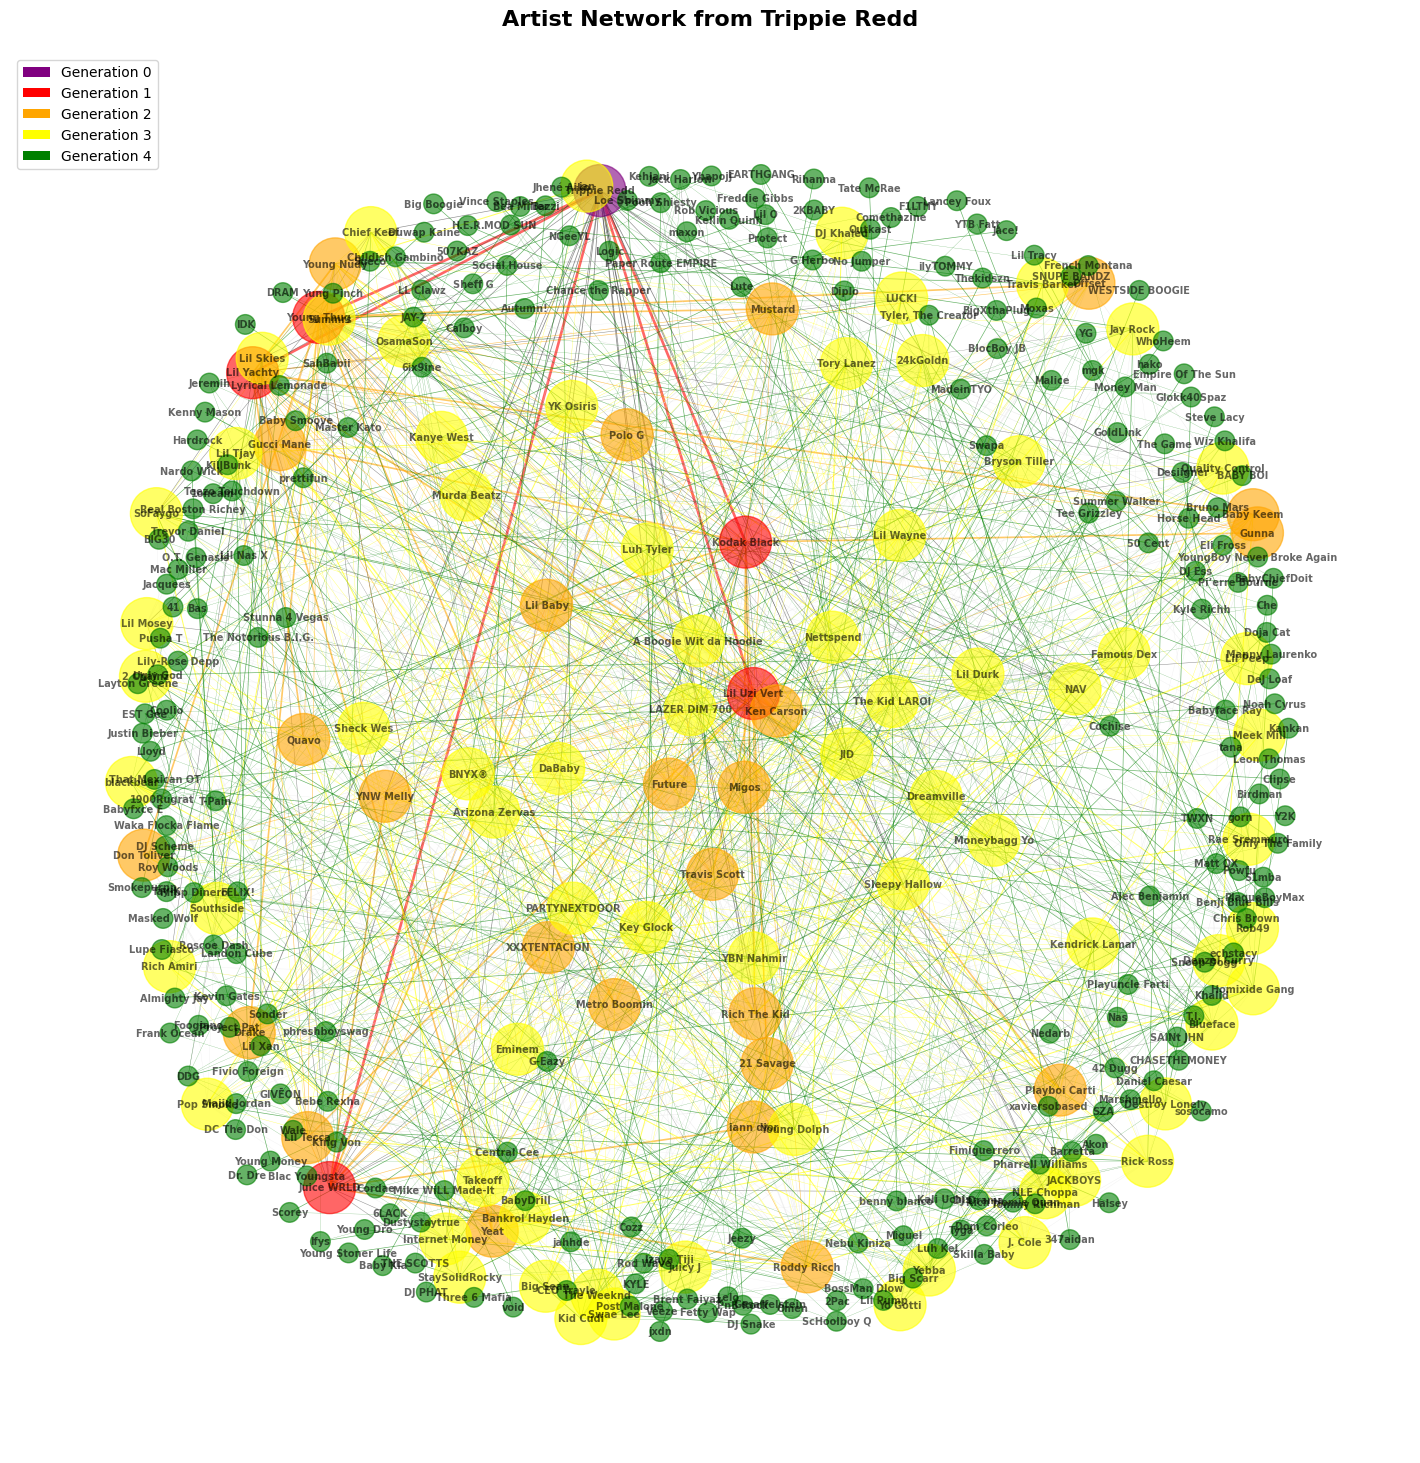

In [12]:
# Cell 11: Create Main Visualization 
# Creates main network graph and displays statistics
G, normalizedNodes = createNetwork(artistData)

nameToGen = {}
for artistId in artistData:
    artistInfo = artistData[artistId]
    nameToGen[artistInfo['name']] = artistInfo['generation']

generationColors = ['purple', 'red', 'orange', 'yellow', 'green', 'cyan', 'blue', 'magenta', 'brown', 'pink']

visualizeNetwork(G, normalizedNodes, artistData, "Artist Network from " + artistName)


Enter generations (Ex: 3):  3


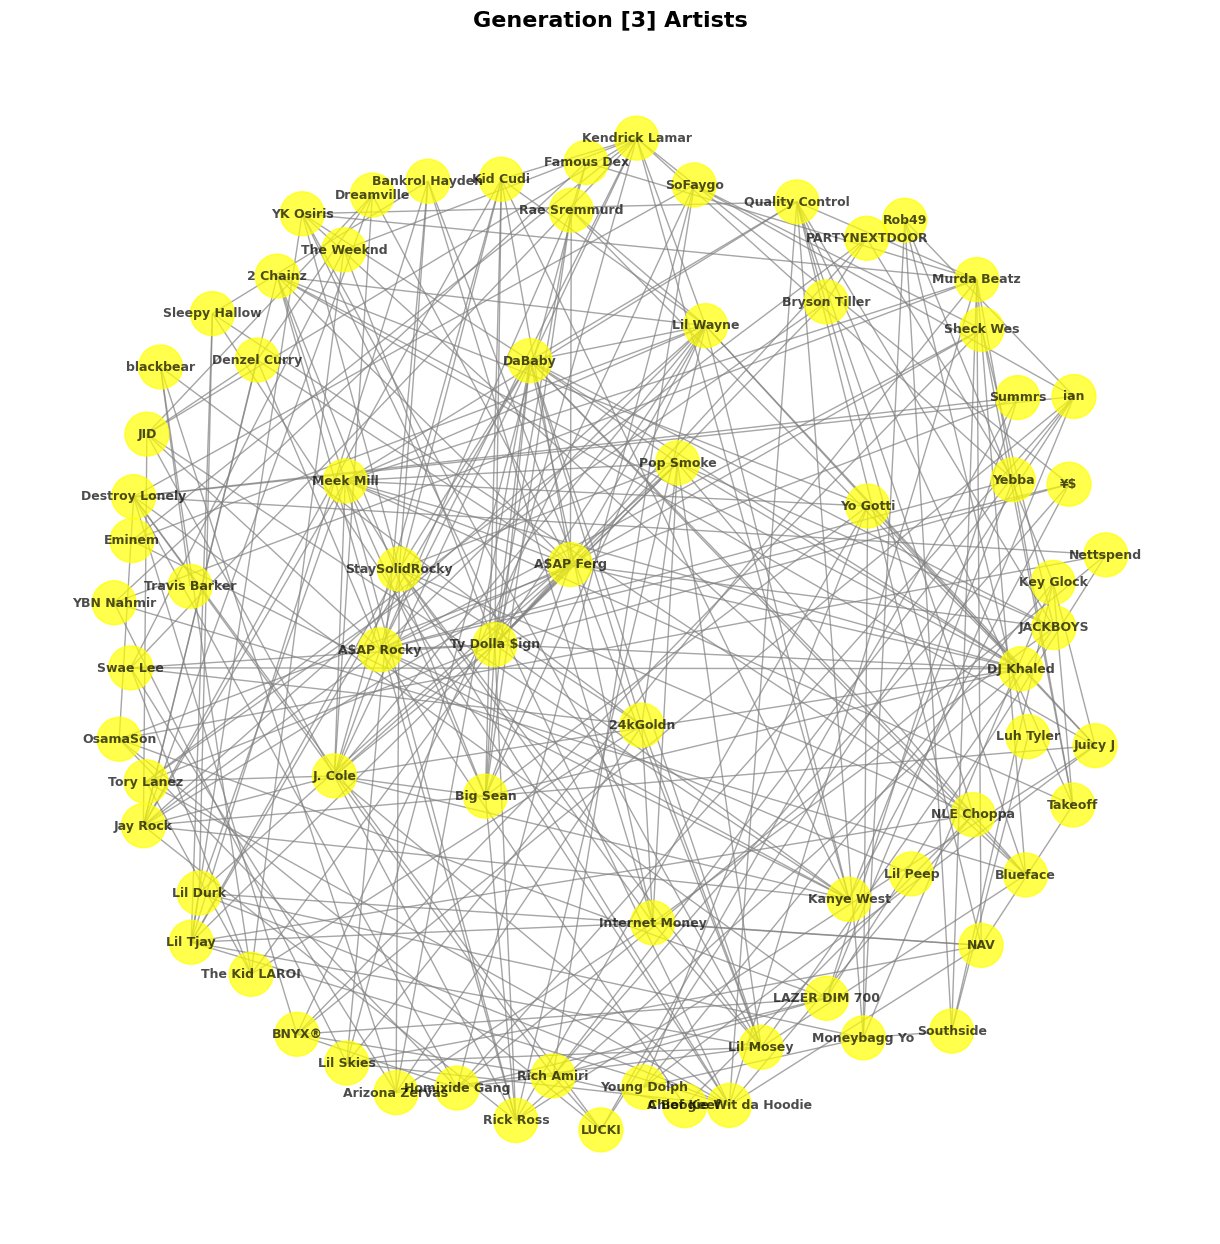

In [13]:
# Cell 12: Generation-Specific Subgraph 
# Views specific generations and their connections
genChoice = input("Enter generations (Ex: 3): ")
selectedGens = [int(g.strip()) for g in genChoice.split(',')]

genNodes = []
for artistName in nameToGen:
    artistGen = nameToGen[artistName]
    if artistGen in selectedGens:
        genNodes.append(artistName)

genSubgraph = G.subgraph(genNodes)

plt.figure(figsize=(12, 12))
layoutPos = nx.spring_layout(genSubgraph, k=1.0, iterations=30)

subNodeColors = []
for node in genSubgraph.nodes():
    gen = nameToGen.get(node, 0)
    subNodeColors.append(generationColors[min(gen, 9)])

nx.draw(genSubgraph, layoutPos,
        with_labels=True,
        node_size=1000,
        node_color=subNodeColors,
        edge_color='gray',
        alpha=0.7,
        font_size=9,
        font_weight='bold')

plt.title("Generation " + str(selectedGens) + " Artists", fontsize=16, fontweight='bold')
plt.show()

# Docs:
# https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html
# https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.spring_layout.html
# https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw.html


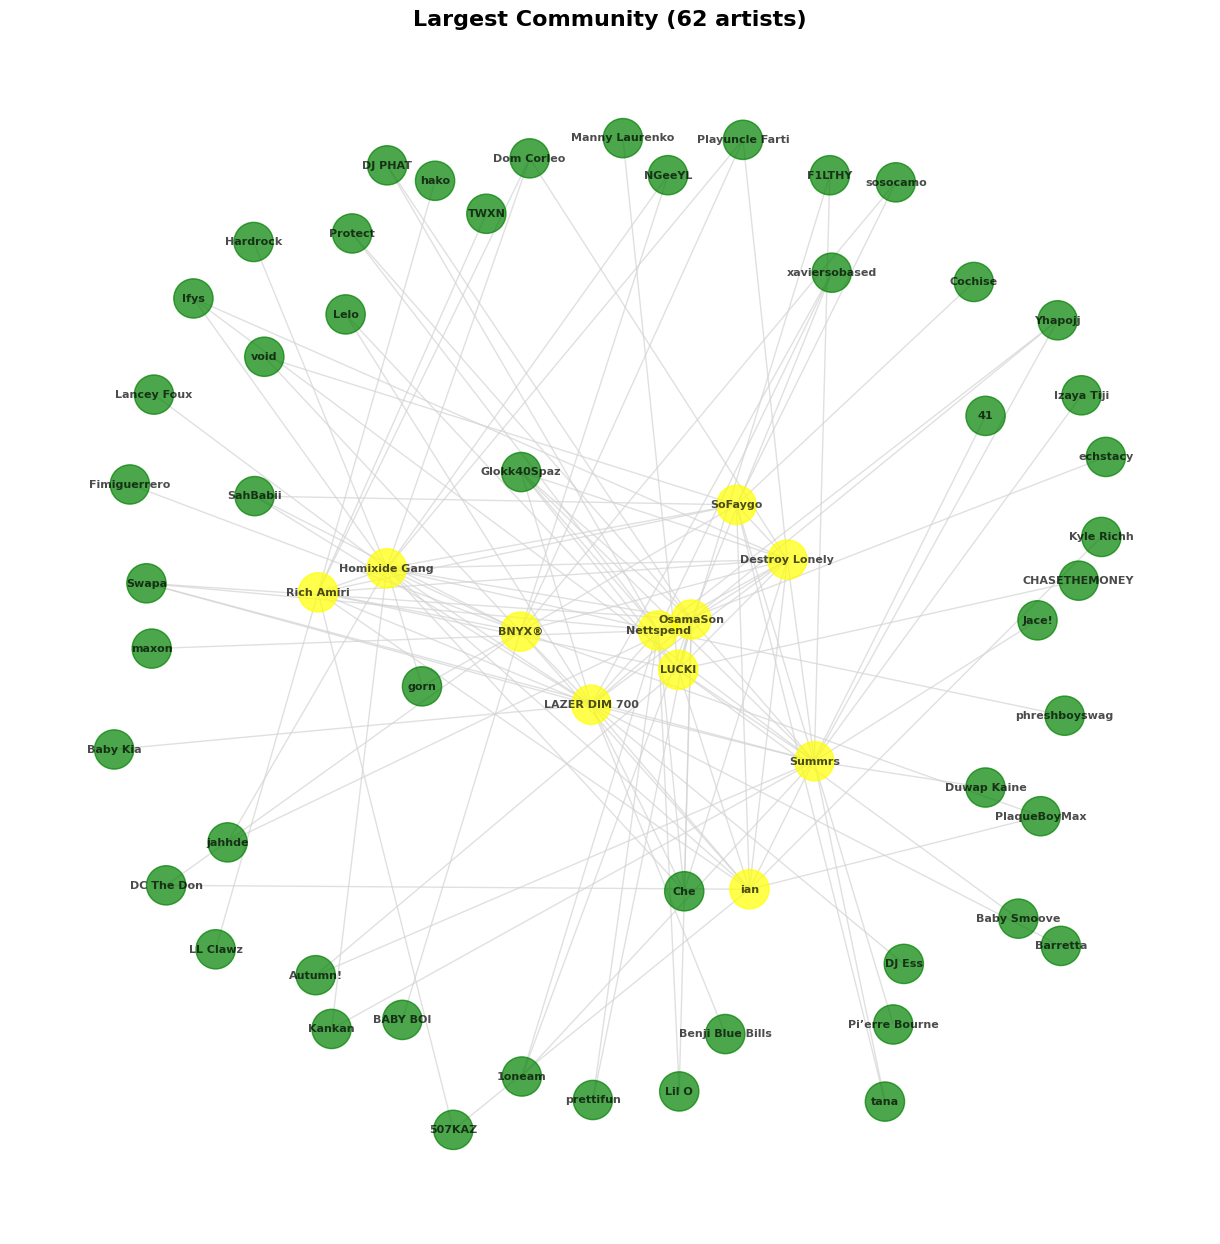

In [14]:
# Cell 13: Community Detection 
# Finds and visualizes clusters in network
import networkx.algorithms.community as nxComm

communities = nxComm.louvain_communities(G, seed=42)
sortedCommunities = sorted(communities, key=len, reverse=True)

largestCommunity = sortedCommunities[0]
communitySubgraph = G.subgraph(largestCommunity)

plt.figure(figsize=(12, 12))
layoutPos = nx.spring_layout(communitySubgraph, k=0.8, iterations=30)

commNodeColors = []
for node in communitySubgraph.nodes():
    gen = nameToGen.get(node, 0)
    commNodeColors.append(generationColors[min(gen, 9)])

nx.draw(communitySubgraph, layoutPos,
        with_labels=True,
        node_size=800,
        node_color=commNodeColors,
        edge_color='lightgray',
        alpha=0.7,
        font_size=8,
        font_weight='bold')

plt.title("Largest Community (" + str(len(largestCommunity)) + " artists)", 
          fontsize=16, fontweight='bold')
plt.show()

# Docs:
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html
# https://networkx.org/documentation/stable/reference/algorithms/community.html


Trippie Redd, Lil Uzi Vert, Juice WRLD, Lil Yachty, Kodak Black, Young Thug, Playboi Carti, Lil Tecca, Future, Travis Scott, 21 Savage, XXXTENTACION, Polo G, YNW Melly, Roddy Ricch, iann dior, Young Nudy, Baby Keem, Yeat, Ken Carson


Enter artist name: (Halsey) iann dior


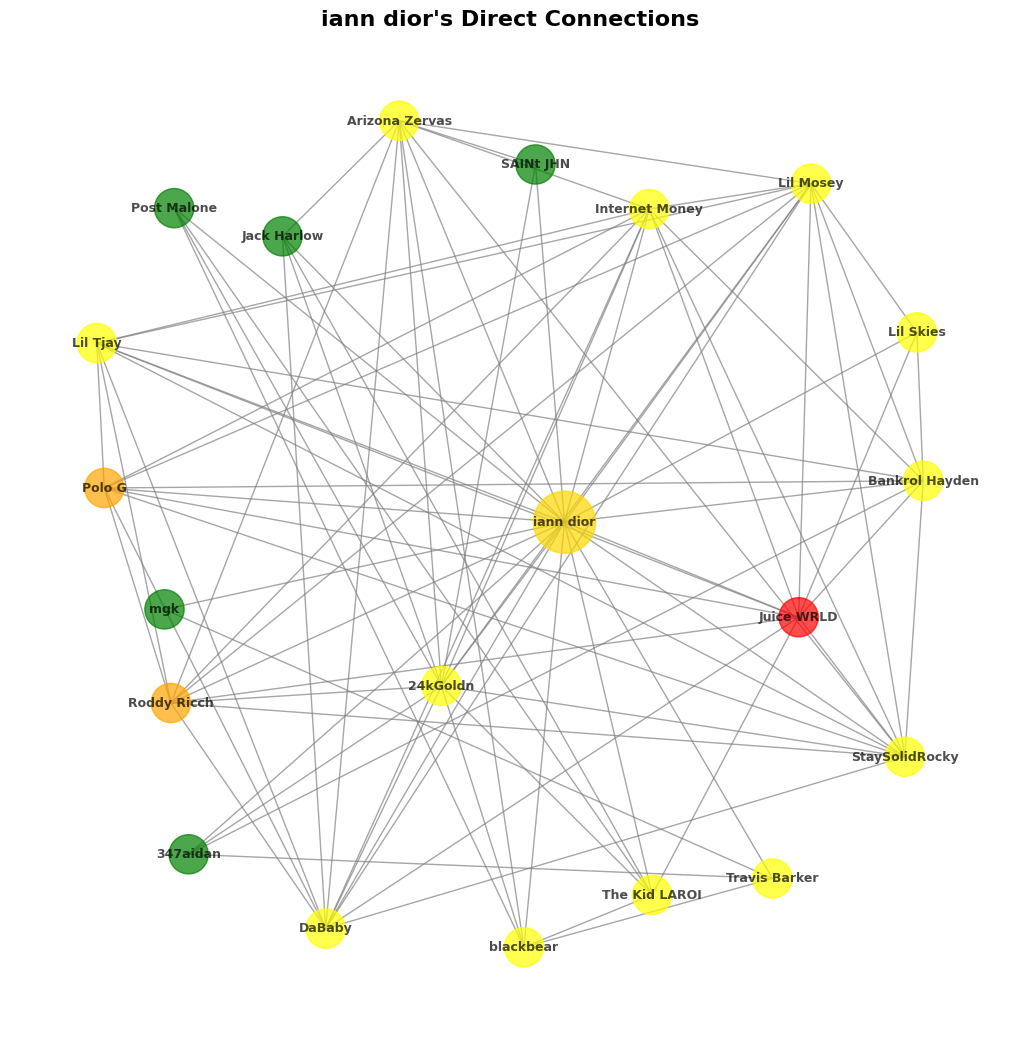

In [15]:
# Cell 14: Ego Network Analysis 
# Shows artist and their direct connections
artistLookup = {}
for name in G.nodes():
    artistLookup[name.lower()] = name

sampleArtists = list(G.nodes())[:20]
print(", ".join(sampleArtists))

centerArtistInput = input("Enter artist name: (Halsey)").strip()
centerArtist = artistLookup.get(centerArtistInput.lower())

if centerArtist:
    egoGraph = nx.ego_graph(G, centerArtist, radius=1)
    
    plt.figure(figsize=(10, 10))
    layoutPos = nx.spring_layout(egoGraph, k=1.5, iterations=30)
    
    egoColors = []
    egoSizes = []
    for node in egoGraph.nodes():
        if node == centerArtist:
            egoColors.append('gold')
            egoSizes.append(2000)
        else:
            gen = nameToGen.get(node, 0)
            egoColors.append(generationColors[min(gen, 9)])
            egoSizes.append(800)
    
    nx.draw(egoGraph, layoutPos,
            with_labels=True,
            node_size=egoSizes,
            node_color=egoColors,
            edge_color='gray',
            alpha=0.7,
            font_size=9,
            font_weight='bold')
    
    plt.title(centerArtist + "'s Direct Connections", fontsize=16, fontweight='bold')
    plt.show()

# Docs:
# https://networkx.org/documentation/stable/reference/generated/networkx.generators.ego.ego_graph.html
# https://networkx.org/documentation/stable/auto_examples/drawing/plot_ego_graph.html
# https://www.geeksforgeeks.org/python/ego-graph-using-networkx-in-python/
